# 🚀 ML/DL Libraries — সব Plot আলাদা আলাদা Cell এ
### NumPy | Pandas | Matplotlib | Seaborn
---

In [31]:
# ✅ Library Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# Dataset Load
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0:'setosa', 1:'versicolor', 2:'virginica'})

housing = fetch_california_housing()
df_house = pd.DataFrame(housing.data, columns=housing.feature_names)
df_house['price'] = housing.target

COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1']
plt.rcParams['figure.dpi'] = 100

print('✅  Ready!')

✅  Ready!


---
# 🔢 PART 1 — NumPy
### NumPy ML/DL তে কী করে?
- সব Data **Array/Matrix** আকারে store হয়
- Weight Matrix, Gradient, Loss Function — সব NumPy Array
- TensorFlow ও PyTorch — এর ভেতরে NumPy আছে

In [32]:
# 1️⃣ NumPy — Array , Shape
print('📦 Array ')
print('=' * 45)

# 1D Array → A Sample of Features
feature = np.array([5.1, 3.5, 1.4, 0.2])
print(f'1D Feature Vector : {feature}')
print(f'Shape             : {feature.shape}  ← 4 feature')

# 2D Array → full Dataset
X = np.array([[5.1,3.5,1.4,0.2],
              [4.9,3.0,1.4,0.2],
              [6.2,3.4,5.4,2.3]])
print(f'\n2D Dataset Shape  : {X.shape}  ← 3 samples, 4 features')
print(X)

# Neural Network Weight Matrix (4 input → 3 neurons)
W = np.random.randn(4, 3)
print(f'\nWeight Matrix Shape: {W.shape}')
print(W.round(3))

# Special Arrays
print(f'\nZeros : {np.zeros(4)}   ← Bias init')
print(f'Ones  : {np.ones(4)}    ← Mask')
print(f'Range : {np.arange(0,1,0.25)}  ← Steps')
print(f'Linspace: {np.linspace(0,1,5)}  ← Uniform')

📦 Array 
1D Feature Vector : [5.1 3.5 1.4 0.2]
Shape             : (4,)  ← 4 feature

2D Dataset Shape  : (3, 4)  ← 3 samples, 4 features
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [6.2 3.4 5.4 2.3]]

Weight Matrix Shape: (4, 3)
[[-0.705 -0.354  0.152]
 [-0.304 -1.179 -0.149]
 [-0.225  0.07   0.452]
 [ 0.294 -0.828 -0.828]]

Zeros : [0. 0. 0. 0.]   ← Bias init
Ones  : [1. 1. 1. 1.]    ← Mask
Range : [0.   0.25 0.5  0.75]  ← Steps
Linspace: [0.   0.25 0.5  0.75 1.  ]  ← Uniform


⚡ Activation Functions — Deep Learning 


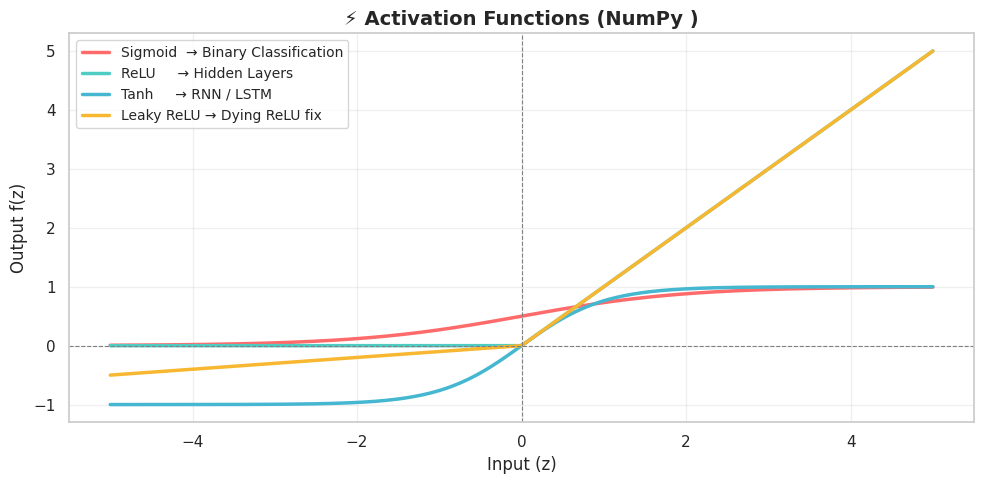

neuron  output function  pass 


In [33]:
# 2️⃣ NumPy — Activation Functions (Visualization)
print('⚡ Activation Functions — Deep Learning ')

z = np.linspace(-5, 5, 300)

sigmoid = 1 / (1 + np.exp(-z))
relu    = np.maximum(0, z)
tanh    = np.tanh(z)
leaky   = np.where(z > 0, z, 0.1 * z)

plt.figure(figsize=(10, 5))
plt.plot(z, sigmoid, color='#FF6B6B', linewidth=2.5, label='Sigmoid  → Binary Classification')
plt.plot(z, relu,    color='#4ECDC4', linewidth=2.5, label='ReLU     → Hidden Layers')
plt.plot(z, tanh,    color='#45B7D1', linewidth=2.5, label='Tanh     → RNN / LSTM')
plt.plot(z, leaky,   color='#F7B731', linewidth=2.5, label='Leaky ReLU → Dying ReLU fix')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('⚡ Activation Functions (NumPy )', fontsize=14, fontweight='bold')
plt.xlabel('Input (z)'); plt.ylabel('Output f(z)')
plt.legend(fontsize=10); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print('neuron  output function  pass ')

🔢 Matrix Multiplication → Neural Network Forward Pass
Input X        : (5, 3)
After Layer 1  : (5, 4)  (ReLU applied)
Output (prob)  : (5, 2)  (Softmax applied)

Class Probabilities (5 samples × 2 classes):
[[0.6186 0.3814]
 [0.7197 0.2803]
 [0.6237 0.3763]
 [0.7995 0.2005]
 [0.9182 0.0818]]

Predicted Classes: [0 0 0 0 0]


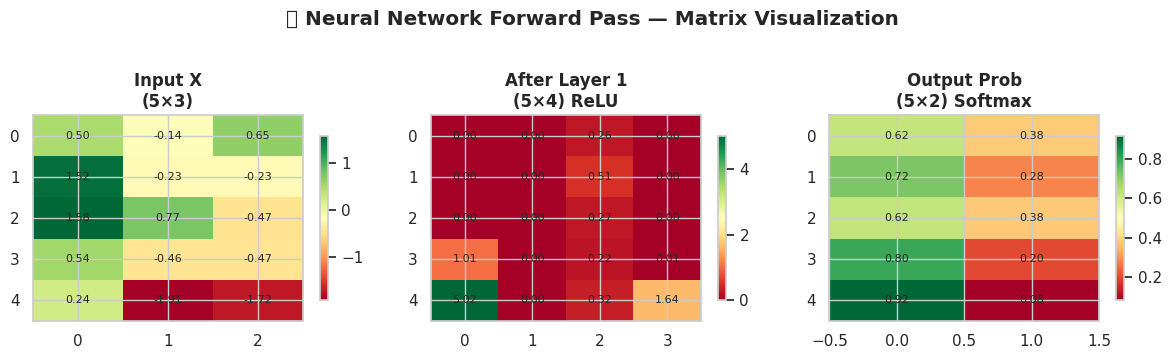

In [34]:
# 3️⃣ NumPy — Matrix Multiplication (Neural Network Forward Pass)
print('🔢 Matrix Multiplication → Neural Network Forward Pass')

np.random.seed(42)
X_batch = np.random.randn(5, 3)  # 5 samples, 3 features
W1 = np.random.randn(3, 4)        # Layer 1: 3→4 neurons
b1 = np.zeros(4)                  # Bias
W2 = np.random.randn(4, 2)        # Layer 2: 4→2 output
b2 = np.zeros(2)

# Forward Pass
Z1 = X_batch @ W1 + b1            # Linear
A1 = np.maximum(0, Z1)            # ReLU
Z2 = A1 @ W2 + b2                 # Linear
exp_z = np.exp(Z2 - Z2.max(axis=1, keepdims=True))
A2 = exp_z / exp_z.sum(axis=1, keepdims=True)  # Softmax

print(f'Input X        : {X_batch.shape}')
print(f'After Layer 1  : {A1.shape}  (ReLU applied)')
print(f'Output (prob)  : {A2.shape}  (Softmax applied)')
print(f'\nClass Probabilities (5 samples × 2 classes):')
print(A2.round(4))
print(f'\nPredicted Classes: {A2.argmax(axis=1)}')

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, data, title in zip(axes,
    [X_batch, A1, A2],
    ['Input X\n(5×3)', 'After Layer 1\n(5×4) ReLU', 'Output Prob\n(5×2) Softmax']):
    im = ax.imshow(data, cmap='RdYlGn', aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f'{data[i,j]:.2f}', ha='center', va='center', fontsize=8)
    ax.set_title(title, fontweight='bold')
plt.suptitle('🧠 Neural Network Forward Pass — Matrix Visualization', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

📉 Loss Functions — ML Training 
Regression Losses:
  MSE  (Mean Squared Error)      : 0.1400  → Outlier sensitive
  MAE  (Mean Absolute Error)     : 0.3600  → Robust to outlier
  RMSE (Root Mean Squared Error) : 0.3742  → Same unit as y

Classification Loss:
  BCE (Binary Cross Entropy)     : 0.2190  → Binary classifier


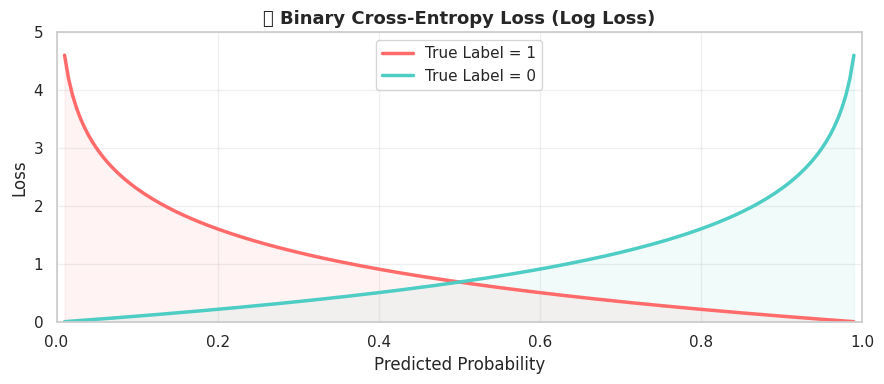

In [35]:
# 4️⃣ NumPy — Loss Functions
print('📉 Loss Functions — ML Training ')

y_true_reg = np.array([3.0, 5.0, 2.5, 7.0, 4.5])
y_pred_reg = np.array([2.8, 5.3, 2.1, 6.5, 4.9])
y_true_cls = np.array([1, 0, 1, 1, 0, 0, 1])
y_pred_prob= np.array([0.9,0.2,0.8,0.7,0.3,0.1,0.85])

mse  = np.mean((y_true_reg - y_pred_reg)**2)
mae  = np.mean(np.abs(y_true_reg - y_pred_reg))
rmse = np.sqrt(mse)
eps  = 1e-10
bce  = -np.mean(y_true_cls * np.log(y_pred_prob + eps) +
                (1-y_true_cls) * np.log(1-y_pred_prob + eps))

print(f'Regression Losses:')
print(f'  MSE  (Mean Squared Error)      : {mse:.4f}  → Outlier sensitive')
print(f'  MAE  (Mean Absolute Error)     : {mae:.4f}  → Robust to outlier')
print(f'  RMSE (Root Mean Squared Error) : {rmse:.4f}  → Same unit as y')
print(f'\nClassification Loss:')
print(f'  BCE (Binary Cross Entropy)     : {bce:.4f}  → Binary classifier')

pred_range = np.linspace(0.01, 0.99, 200)
loss_1 = -np.log(pred_range)       # y=1
loss_0 = -np.log(1 - pred_range)   # y=0

plt.figure(figsize=(9, 4))
plt.plot(pred_range, loss_1, '#FF6B6B', linewidth=2.5, label='True Label = 1')
plt.plot(pred_range, loss_0, '#4ECDC4', linewidth=2.5, label='True Label = 0')
plt.fill_between(pred_range, loss_1, alpha=0.08, color='#FF6B6B')
plt.fill_between(pred_range, loss_0, alpha=0.08, color='#4ECDC4')
plt.ylim(0, 5); plt.xlim(0, 1)
plt.title('📉 Binary Cross-Entropy Loss (Log Loss)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Probability'); plt.ylabel('Loss')
plt.legend(fontsize=11); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

⚖️ Feature Normalization — ML 


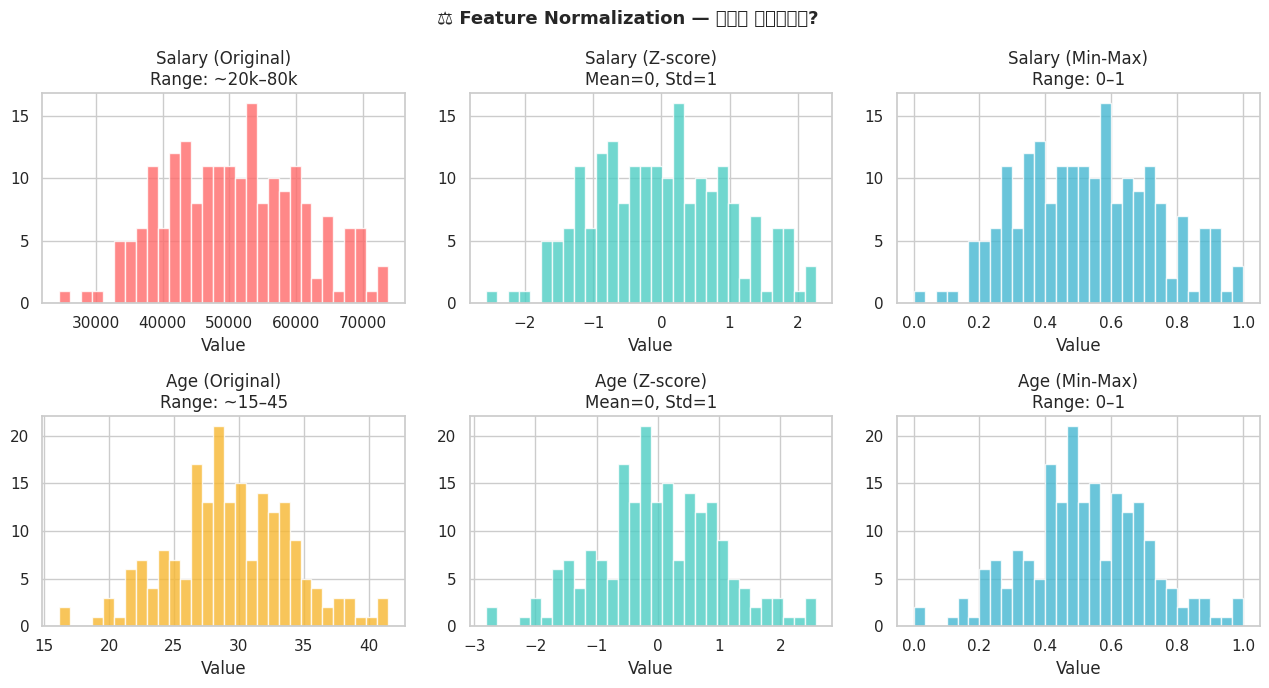

💡 Normalization এর পর দুটো feature একই scale এ আসে → Model আরো ভালো শেখে


In [36]:
# 5️⃣ NumPy — Feature Normalization
print('⚖️ Feature Normalization — ML ')

np.random.seed(0)
feature_A = np.random.normal(50000, 10000, 200)   # Salary (বড় মান)
feature_B = np.random.normal(30, 5, 200)            # Age (ছোট মান)

A_zscore = (feature_A - feature_A.mean()) / feature_A.std()
B_zscore = (feature_B - feature_B.mean()) / feature_B.std()
A_minmax = (feature_A - feature_A.min()) / (feature_A.max() - feature_A.min())
B_minmax = (feature_B - feature_B.min()) / (feature_B.max() - feature_B.min())

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.suptitle('⚖️ Feature Normalization — কেন দরকার?', fontsize=13, fontweight='bold')

axes[0,0].hist(feature_A, bins=30, color='#FF6B6B', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Salary (Original)\nRange: ~20k–80k'); axes[0,0].set_xlabel('Value')

axes[0,1].hist(A_zscore, bins=30, color='#4ECDC4', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Salary (Z-score)\nMean=0, Std=1'); axes[0,1].set_xlabel('Value')

axes[0,2].hist(A_minmax, bins=30, color='#45B7D1', edgecolor='white', alpha=0.8)
axes[0,2].set_title('Salary (Min-Max)\nRange: 0–1'); axes[0,2].set_xlabel('Value')

axes[1,0].hist(feature_B, bins=30, color='#F7B731', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Age (Original)\nRange: ~15–45'); axes[1,0].set_xlabel('Value')

axes[1,1].hist(B_zscore, bins=30, color='#4ECDC4', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Age (Z-score)\nMean=0, Std=1'); axes[1,1].set_xlabel('Value')

axes[1,2].hist(B_minmax, bins=30, color='#45B7D1', edgecolor='white', alpha=0.8)
axes[1,2].set_title('Age (Min-Max)\nRange: 0–1'); axes[1,2].set_xlabel('Value')

plt.tight_layout(); plt.show()
print('💡 Normalization এর পর দুটো feature একই scale এ আসে → Model আরো ভালো শেখে')

---
# 🐼 PART 2 — Pandas
### Pandas ML তে কী করে?
- CSV/Excel/SQL থেকে Data Load
- Missing Value, Duplicate Handle
- Feature Engineering
- Train/Test Split এর আগে সব Preprocessing

In [37]:
# 6️⃣ Pandas — Dataset Load
print('📂 Dataset Load ও Basic Info')
print('=' * 45)

print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nপ্রথম ৫ row:')
display(df.head())
print(f'\nশেষ ৩ row:')
display(df.tail(3))
print(f'\nColumn Names: {list(df.columns)}')
print(f'Data Types:\n{df.dtypes}')

📂 Dataset Load ও Basic Info
Dataset Shape: 150 rows × 6 columns

প্রথম ৫ row:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



শেষ ৩ row:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica



Column Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species', 'species_name']
Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object


In [38]:
# 7️⃣ Pandas — Statistical Summary (EDA)
print('📊 Statistical Summary — ML শুরুর আগে অবশ্যই দেখো')
display(df.describe().round(3))
print('\n📋 Info (Data Types + Non-null Count):')
df.info()
print(f'\n❓ Missing Values per Column:')
print(df.isnull().sum())
print(f'\n🔁 Duplicate Rows: {df.duplicated().sum()}')
print(f'\n📊 Class Distribution:')
print(df['species_name'].value_counts())

📊 Statistical Summary — ML শুরুর আগে অবশ্যই দেখো


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199,1.000
std,0.828,0.436,1.765,0.762,0.819
min,4.300,2.000,1.000,0.100,0.000
25%,5.100,2.800,1.600,0.300,0.000
50%,5.800,3.000,4.350,1.300,1.000
75%,6.400,3.300,5.100,1.800,2.000
max,7.900,4.400,6.900,2.500,2.000



📋 Info (Data Types + Non-null Count):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

❓ Missing Values per Column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

🔁 Duplicate Rows: 1

📊 Class Distribution:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


🧹 Missing Value Handling
Missing আগে  : 20 টি null আছে
Mean Fill    : 0 null বাকি
Median Fill  : 0 null বাকি
Drop Rows    : 130 rows থাকলো (150 → 130)
Forward Fill : 0 null বাকি


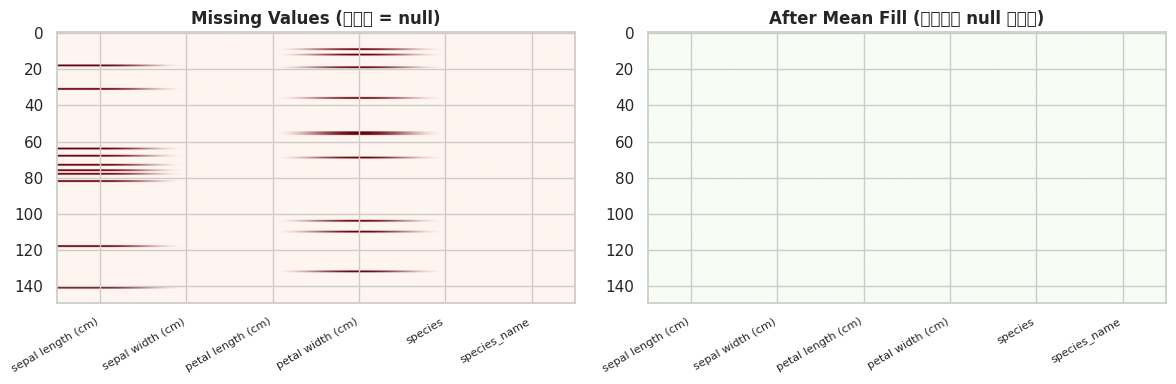

In [39]:
# 8️⃣ Pandas — Missing Value Handle
print('🧹 Missing Value Handling')

df_dirty = df.copy()
np.random.seed(42)
idx = np.random.choice(df_dirty.index, 20, replace=False)
df_dirty.loc[idx[:10], 'sepal length (cm)'] = np.nan
df_dirty.loc[idx[10:], 'petal width (cm)'] = np.nan

print(f'Missing আগে  : {df_dirty.isnull().sum().sum()} টি null আছে')

# পদ্ধতি ১: Mean দিয়ে Fill
df_mean = df_dirty.fillna(df_dirty.mean(numeric_only=True))
print(f'Mean Fill    : {df_mean.isnull().sum().sum()} null বাকি')

# পদ্ধতি ২: Median দিয়ে Fill (Outlier থাকলে ভালো)
df_med = df_dirty.fillna(df_dirty.median(numeric_only=True))
print(f'Median Fill  : {df_med.isnull().sum().sum()} null বাকি')

# পদ্ধতি ৩: Row Drop
df_drop = df_dirty.dropna()
print(f'Drop Rows    : {df_drop.shape[0]} rows থাকলো ({df_dirty.shape[0]} → {df_drop.shape[0]})')

# পদ্ধতি ৪: Forward Fill (Time Series)
df_ffill = df_dirty.fillna(method='ffill')
print(f'Forward Fill : {df_ffill.isnull().sum().sum()} null বাকি')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(df_dirty.isnull(), cmap='Reds', aspect='auto')
axes[0].set_title('Missing Values (লাল = null)', fontweight='bold')
axes[0].set_xticks(range(len(df_dirty.columns)))
axes[0].set_xticklabels(df_dirty.columns, rotation=30, ha='right', fontsize=8)

axes[1].imshow(df_mean.isnull(), cmap='Greens', aspect='auto')
axes[1].set_title('After Mean Fill (কোনো null নেই)', fontweight='bold')
axes[1].set_xticks(range(len(df_mean.columns)))
axes[1].set_xticklabels(df_mean.columns, rotation=30, ha='right', fontsize=8)

plt.tight_layout(); plt.show()

In [40]:
# 9️⃣ Pandas — Feature Engineering
print('🔧 Feature Engineering — নতুন Feature তৈরি করা')

df_fe = df.copy()

# নতুন features
df_fe['petal_area']      = df_fe['petal length (cm)'] * df_fe['petal width (cm)']
df_fe['sepal_area']      = df_fe['sepal length (cm)'] * df_fe['sepal width (cm)']
df_fe['sepal_ratio']     = df_fe['sepal length (cm)'] / df_fe['sepal width (cm)']
df_fe['petal_ratio']     = df_fe['petal length (cm)'] / df_fe['petal width (cm)']
df_fe['total_size']      = df_fe['petal_area'] + df_fe['sepal_area']
df_fe['sepal_big']       = (df_fe['sepal length (cm)'] > 5.5).astype(int)

new_cols = ['petal_area','sepal_area','sepal_ratio','petal_ratio','total_size','sepal_big']
print('নতুন Features:')
display(df_fe[new_cols + ['species_name']].head(8))

# GroupBy Statistics
print('\n📊 Species অনুযায়ী নতুন Feature Statistics:')
display(df_fe.groupby('species_name')[new_cols[:4]].mean().round(3))

🔧 Feature Engineering — নতুন Feature তৈরি করা
নতুন Features:


,petal_area,sepal_area,sepal_ratio,petal_ratio,total_size,sepal_big,species_name
0,0.28,17.85,1.457143,7.000000,18.13,0,setosa
1,0.28,14.70,1.633333,7.000000,14.98,0,setosa
2,0.26,15.04,1.468750,6.500000,15.30,0,setosa
3,0.30,14.26,1.483871,7.500000,14.56,0,setosa
4,0.28,18.00,1.388889,7.000000,18.28,0,setosa
5,0.68,21.06,1.384615,4.250000,21.74,0,setosa
6,0.42,15.64,1.352941,4.666667,16.06,0,setosa
7,0.30,17.00,1.470588,7.500000,17.30,0,setosa



📊 Species অনুযায়ী নতুন Feature Statistics:


,petal_area,sepal_area,sepal_ratio,petal_ratio
species_name,,,,
setosa,0.366,17.258,1.47,6.908
versicolor,5.720,16.526,2.16,3.243
virginica,11.296,19.685,2.23,2.781


🔗 Correlation Analysis — কোন Feature কার সাথে related?
Correlation Matrix:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000,-0.118,0.872,0.818
sepal width (cm),-0.118,1.000,-0.428,-0.366
petal length (cm),0.872,-0.428,1.000,0.963
petal width (cm),0.818,-0.366,0.963,1.000


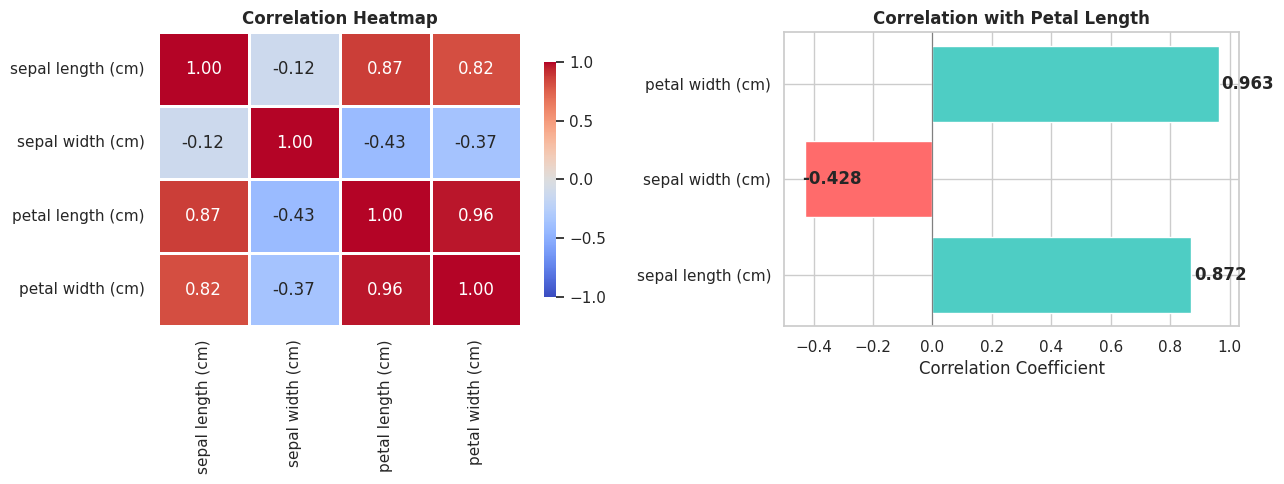

💡 Correlation ±1 এর কাছে = strong relationship


In [41]:
# 🔟 Pandas — Correlation Matrix (Visualization)
print('🔗 Correlation Analysis — কোন Feature কার সাথে related?')

corr = df.iloc[:, :4].corr()
print('Correlation Matrix:')
display(corr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], vmin=-1, vmax=1, linewidths=1,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Heatmap', fontweight='bold', fontsize=12)

# Bar chart of correlations with petal length
target_corr = corr['petal length (cm)'].drop('petal length (cm)')
colors_bar = ['#FF6B6B' if v < 0 else '#4ECDC4' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_title('Correlation with Petal Length', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Correlation Coefficient')
for i, v in enumerate(target_corr):
    axes[1].text(v + 0.01 if v >= 0 else v - 0.01, i,
                 f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout(); plt.show()
print('💡 Correlation ±1 এর কাছে = strong relationship')

---
# 📊 PART 3 — Matplotlib
### মোট 10টি আলাদা Plot — প্রতিটি আলাদা Cell এ

📉 Line Plot — DL Training এ সবচেয়ে বেশি দেখা যায়


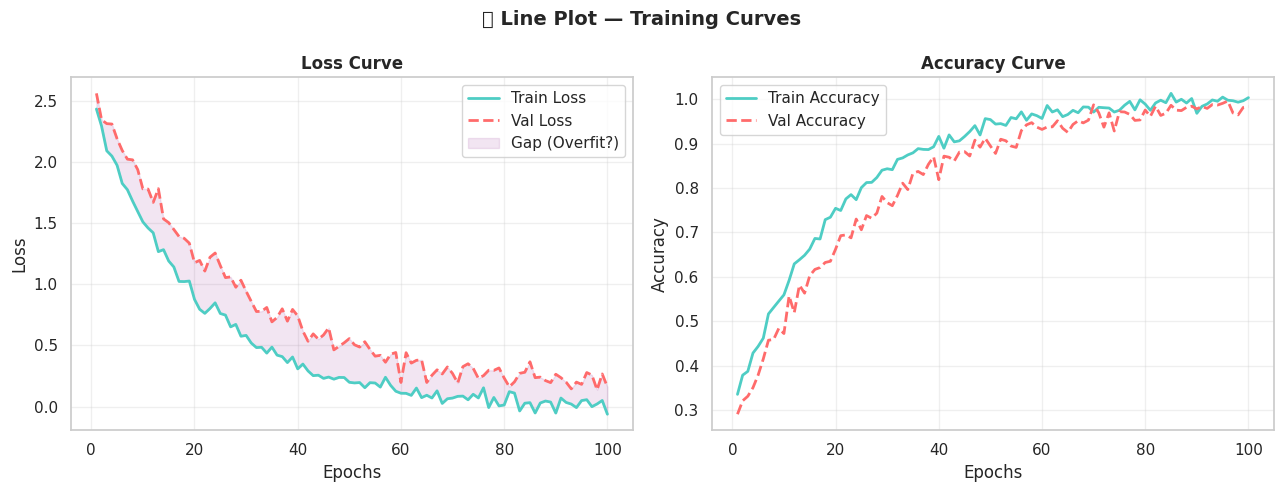

ব্যবহার: কখন overfitting শুরু হচ্ছে বোঝা যায়


In [42]:
# 1️⃣ Matplotlib — Line Plot (Training Curve)
print('📉 Line Plot — DL Training এ সবচেয়ে বেশি দেখা যায়')

epochs = np.arange(1, 101)
np.random.seed(10)
train_loss = 2.5 * np.exp(-0.05 * epochs) + np.random.normal(0, 0.04, 100)
val_loss   = 2.5 * np.exp(-0.04 * epochs) + np.random.normal(0, 0.06, 100) + 0.15
train_acc  = 1 - 0.7 * np.exp(-0.05 * epochs) + np.random.normal(0, 0.01, 100)
val_acc    = 1 - 0.75 * np.exp(-0.04 * epochs) + np.random.normal(0, 0.015, 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epochs, train_loss, '#4ECDC4', linewidth=2, label='Train Loss')
ax1.plot(epochs, val_loss, '#FF6B6B', linewidth=2, linestyle='--', label='Val Loss')
ax1.fill_between(epochs, train_loss, val_loss, alpha=0.1, color='purple', label='Gap (Overfit?)')
ax1.set_title('Loss Curve', fontweight='bold', fontsize=12)
ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_acc, '#4ECDC4', linewidth=2, label='Train Accuracy')
ax2.plot(epochs, val_acc, '#FF6B6B', linewidth=2, linestyle='--', label='Val Accuracy')
ax2.set_title('Accuracy Curve', fontweight='bold', fontsize=12)
ax2.set_xlabel('Epochs'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('📉 Line Plot — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('ব্যবহার: কখন overfitting শুরু হচ্ছে বোঝা যায়')

🔵 Scatter Plot — Feature Relationship ও Class Separation


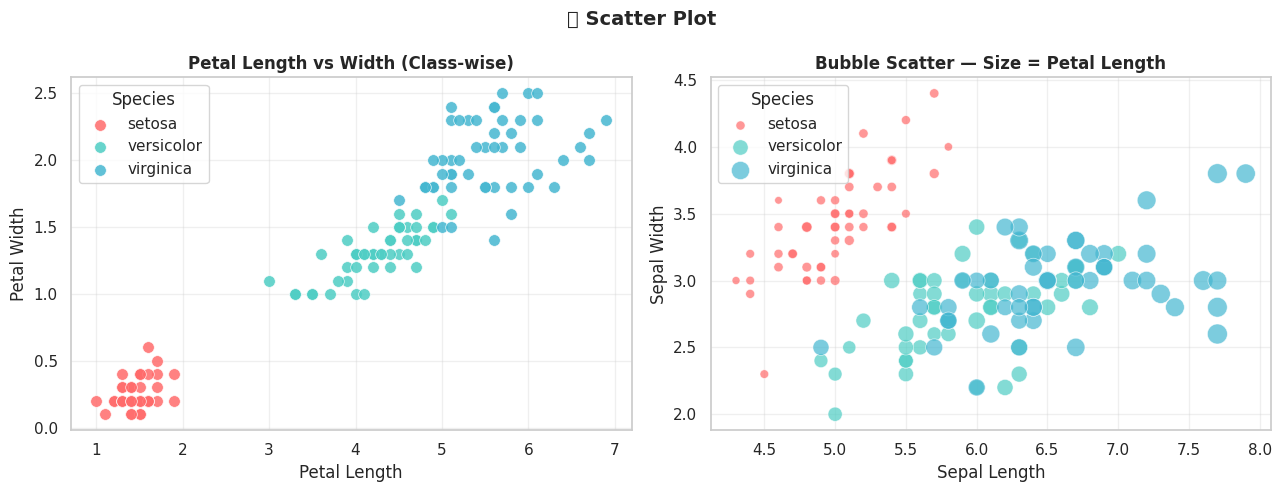

In [43]:
# 2️⃣ Matplotlib — Scatter Plot
print('🔵 Scatter Plot — Feature Relationship ও Class Separation')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Class-wise Scatter
for sp, color in zip(['setosa','versicolor','virginica'], COLORS):
    mask = df['species_name'] == sp
    axes[0].scatter(df[mask]['petal length (cm)'],
                    df[mask]['petal width (cm)'],
                    c=color, label=sp, s=70, alpha=0.85, edgecolors='white', linewidths=0.5)
axes[0].set_title('Petal Length vs Width (Class-wise)', fontweight='bold')
axes[0].set_xlabel('Petal Length'); axes[0].set_ylabel('Petal Width')
axes[0].legend(title='Species'); axes[0].grid(True, alpha=0.3)

# Bubble Scatter (3rd variable = size)
for sp, color in zip(['setosa','versicolor','virginica'], COLORS):
    mask = df['species_name'] == sp
    axes[1].scatter(df[mask]['sepal length (cm)'],
                    df[mask]['sepal width (cm)'],
                    c=color, label=sp, s=df[mask]['petal length (cm)']*30,
                    alpha=0.7, edgecolors='white', linewidths=0.5)
axes[1].set_title('Bubble Scatter — Size = Petal Length', fontweight='bold')
axes[1].set_xlabel('Sepal Length'); axes[1].set_ylabel('Sepal Width')
axes[1].legend(title='Species'); axes[1].grid(True, alpha=0.3)

plt.suptitle('🔵 Scatter Plot', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

📊 Bar Plot — Feature Importance, Class Count


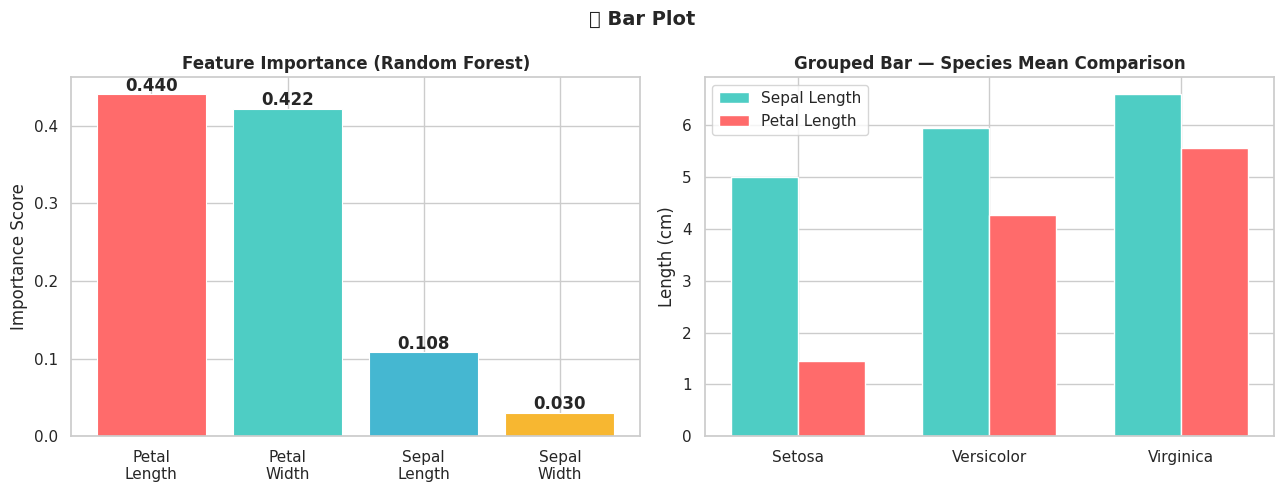

In [44]:
# 3️⃣ Matplotlib — Bar Plot
print('📊 Bar Plot — Feature Importance, Class Count')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Feature Importance (from Random Forest)
X_tr, X_te, y_tr, y_te = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr, y_tr)
feat_names = ['Sepal\nLength','Sepal\nWidth','Petal\nLength','Petal\nWidth']
imp = rf.feature_importances_
sorted_idx = np.argsort(imp)[::-1]
bar_colors = ['#FF6B6B','#4ECDC4','#45B7D1','#F7B731']
bars = axes[0].bar([feat_names[i] for i in sorted_idx], imp[sorted_idx],
                   color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, imp[sorted_idx]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontweight='bold')
axes[0].set_title('Feature Importance (Random Forest)', fontweight='bold')
axes[0].set_ylabel('Importance Score')

# Grouped Bar
species_list = ['Setosa', 'Versicolor', 'Virginica']
means = df.groupby('species_name')[['sepal length (cm)','petal length (cm)']].mean()
x = np.arange(len(species_list))
w = 0.35
axes[1].bar(x - w/2, means['sepal length (cm)'], w, label='Sepal Length', color='#4ECDC4', edgecolor='white')
axes[1].bar(x + w/2, means['petal length (cm)'], w, label='Petal Length', color='#FF6B6B', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(species_list)
axes[1].set_title('Grouped Bar — Species Mean Comparison', fontweight='bold')
axes[1].set_ylabel('Length (cm)'); axes[1].legend()

plt.suptitle('📊 Bar Plot', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

📊 Histogram — Data Distribution দেখা


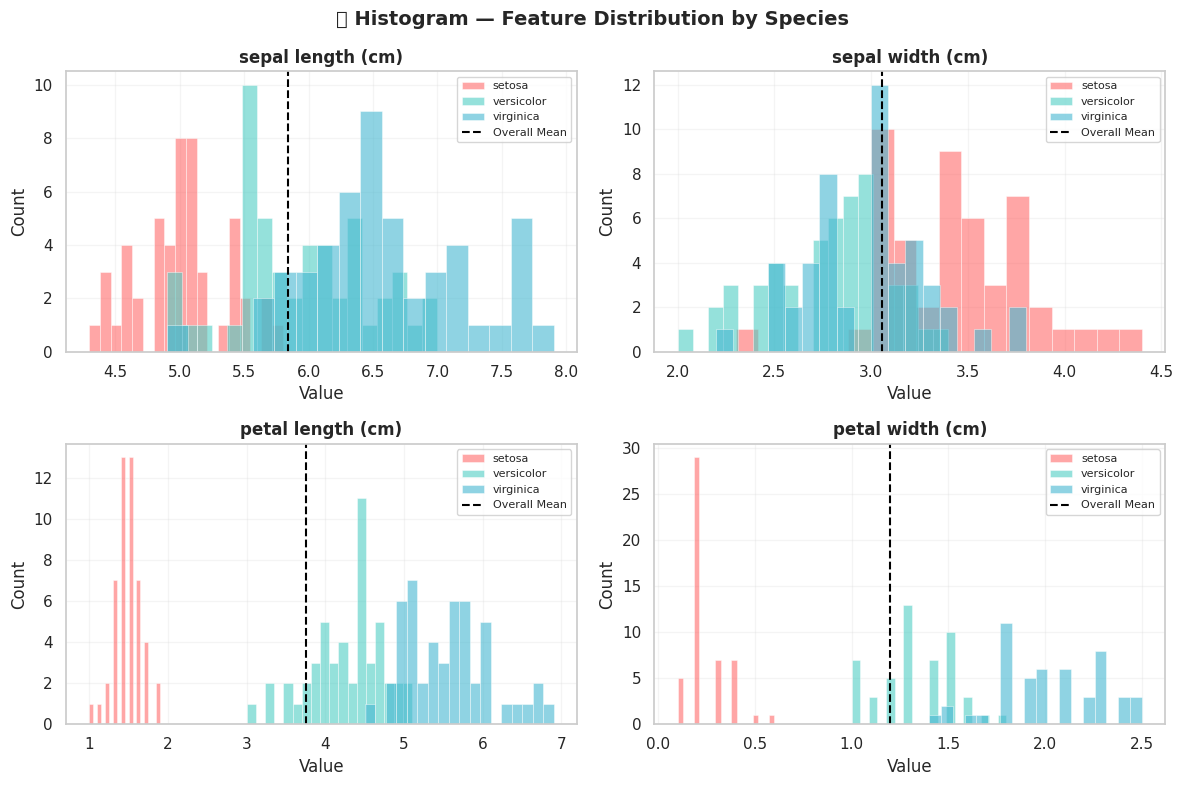

ব্যবহার: Feature skewness, bimodal distribution, outlier বোঝা যায়


In [45]:
# 4️⃣ Matplotlib — Histogram
print('📊 Histogram — Data Distribution দেখা')

features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    for sp, color in zip(['setosa','versicolor','virginica'], COLORS):
        mask = df['species_name'] == sp
        ax.hist(df[mask][feat], bins=18, alpha=0.6, color=color,
                label=sp, edgecolor='white', linewidth=0.5)
    ax.axvline(df[feat].mean(), color='black', linewidth=1.5, linestyle='--', label='Overall Mean')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('📊 Histogram — Feature Distribution by Species', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('ব্যবহার: Feature skewness, bimodal distribution, outlier বোঝা যায়')

📦 Box Plot — Outlier Detection


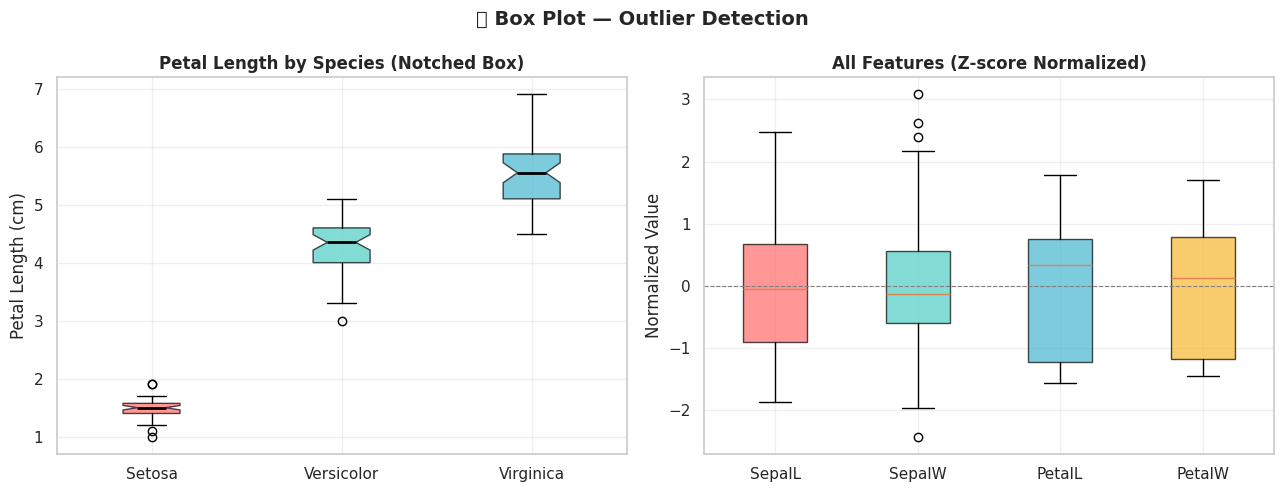

Box Plot বলে: median, IQR, outlier (ফুটকি) — এক নজরে


In [46]:
# 5️⃣ Matplotlib — Box Plot
print('📦 Box Plot — Outlier Detection')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box Plot by Species
data_by_sp = [df[df['species_name']==sp]['petal length (cm)'].values
              for sp in ['setosa','versicolor','virginica']]
bp = axes[0].boxplot(data_by_sp, labels=['Setosa','Versicolor','Virginica'],
                     patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('black'); median.set_linewidth(2)
axes[0].set_title('Petal Length by Species (Notched Box)', fontweight='bold')
axes[0].set_ylabel('Petal Length (cm)')
axes[0].grid(True, alpha=0.3)

# All Features Box Plot
df_scaled = df.copy()
for feat in features:
    df_scaled[feat] = (df[feat] - df[feat].mean()) / df[feat].std()
bp2 = axes[1].boxplot([df_scaled[f].values for f in features],
                       labels=['SepalL','SepalW','PetalL','PetalW'],
                       patch_artist=True)
box_colors = ['#FF6B6B','#4ECDC4','#45B7D1','#F7B731']
for patch, c in zip(bp2['boxes'], box_colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title('All Features (Z-score Normalized)', fontweight='bold')
axes[1].set_ylabel('Normalized Value')
axes[1].grid(True, alpha=0.3)

plt.suptitle('📦 Box Plot — Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('Box Plot বলে: median, IQR, outlier (ফুটকি) — এক নজরে')

🥧 Pie Chart — Class Distribution


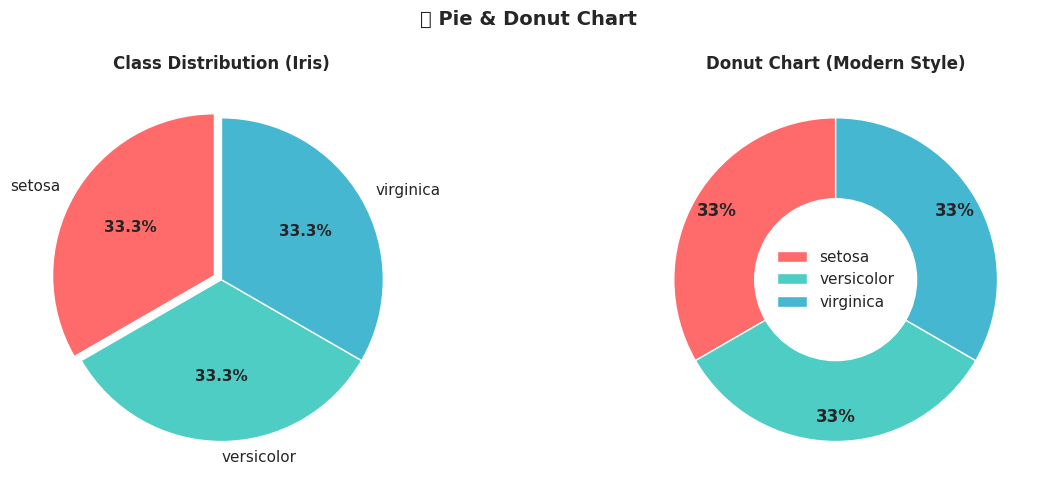

⚠️ Pie Chart: Class Imbalance সমস্যা বোঝার জন্য গুরুত্বপূর্ণ


In [47]:
# 6️⃣ Matplotlib — Pie Chart
print('🥧 Pie Chart — Class Distribution')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Standard Pie
counts = df['species_name'].value_counts()
wedges, texts, autotexts = axes[0].pie(
    counts, labels=counts.index, colors=COLORS,
    autopct='%1.1f%%', startangle=90, explode=[0.05, 0, 0],
    shadow=False, textprops={'fontsize': 11})
for at in autotexts: at.set_fontweight('bold')
axes[0].set_title('Class Distribution (Iris)', fontweight='bold')

# Donut Chart (আধুনিক)
wedges2, _, autotexts2 = axes[1].pie(
    counts, colors=COLORS, autopct='%1.0f%%',
    startangle=90, pctdistance=0.85,
    wedgeprops={'width': 0.5})
for at in autotexts2: at.set_fontweight('bold'); at.set_fontsize(12)
axes[1].legend(counts.index, loc='center', frameon=False)
axes[1].set_title('Donut Chart (Modern Style)', fontweight='bold')

plt.suptitle('🥧 Pie & Donut Chart', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('⚠️ Pie Chart: Class Imbalance সমস্যা বোঝার জন্য গুরুত্বপূর্ণ')

🔲 Confusion Matrix — Classification Result দেখা


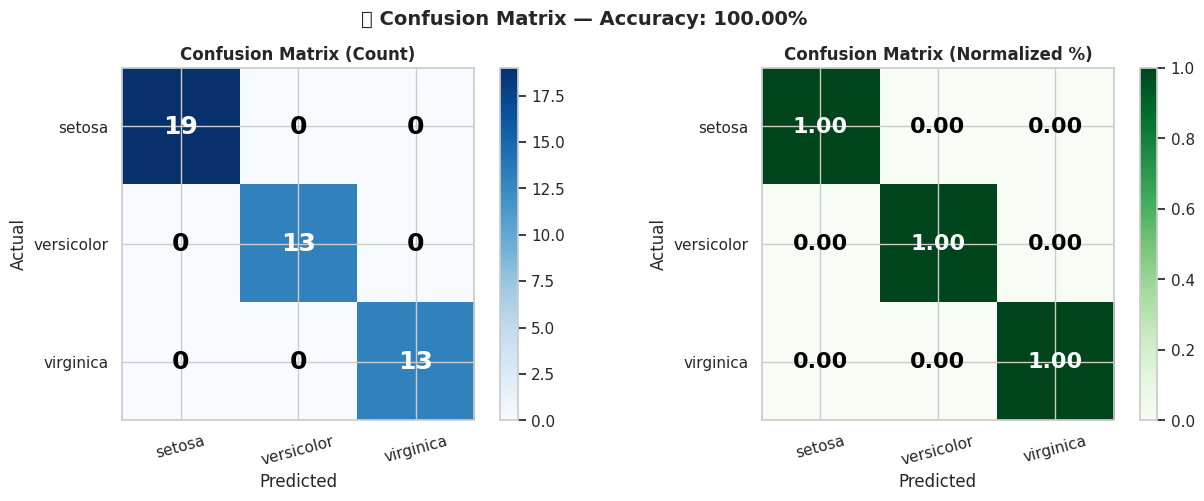

In [48]:
# 7️⃣ Matplotlib — Confusion Matrix
print('🔲 Confusion Matrix — Classification Result দেখা')

X_tr, X_te, y_tr, y_te = train_test_split(iris.data, iris.target, test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
y_pred = model.predict(X_te)
cm = confusion_matrix(y_te, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw Counts
im = axes[0].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[0])
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, cm[i,j], ha='center', va='center', fontsize=18, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
axes[0].set_xticks([0,1,2]); axes[0].set_yticks([0,1,2])
axes[0].set_xticklabels(iris.target_names, rotation=15)
axes[0].set_yticklabels(iris.target_names)
axes[0].set_title('Confusion Matrix (Count)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im2 = axes[1].imshow(cm_norm, cmap='Greens', vmin=0, vmax=1)
plt.colorbar(im2, ax=axes[1])
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm_norm[i,j] > 0.5 else 'black')
axes[1].set_xticks([0,1,2]); axes[1].set_yticks([0,1,2])
axes[1].set_xticklabels(iris.target_names, rotation=15)
axes[1].set_yticklabels(iris.target_names)
axes[1].set_title('Confusion Matrix (Normalized %)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.suptitle(f'🔲 Confusion Matrix — Accuracy: {accuracy_score(y_te, y_pred):.2%}',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

📈 ROC Curve — Classifier এর Performance মাপা


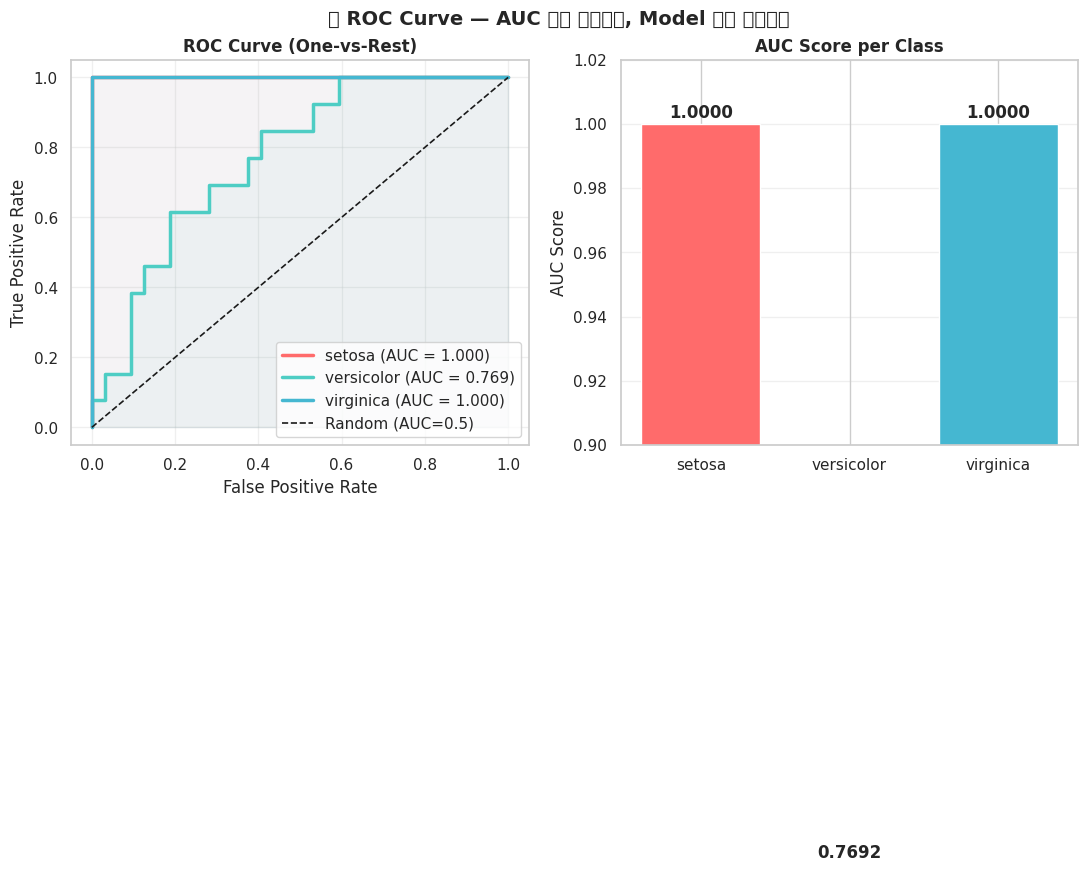

In [49]:
# 8️⃣ Matplotlib — ROC Curve
print('📈 ROC Curve — Classifier এর Performance মাপা')

y_bin = label_binarize(iris.target, classes=[0,1,2])
X_tr, X_te, y_tr, y_te = train_test_split(iris.data, y_bin, test_size=0.3, random_state=42)
clf = OneVsRestClassifier(LogisticRegression(max_iter=1000)).fit(X_tr, y_tr)
y_score = clf.predict_proba(X_te)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

roc_aucs = []
for i, (color, name) in enumerate(zip(COLORS, iris.target_names)):
    fpr, tpr, _ = roc_curve(y_te[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    roc_aucs.append(roc_auc)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{name} (AUC = {roc_auc:.3f})')
    axes[0].fill_between(fpr, tpr, alpha=0.05, color=color)

axes[0].plot([0,1],[0,1],'k--',linewidth=1.2, label='Random (AUC=0.5)')
axes[0].set_title('ROC Curve (One-vs-Rest)', fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right'); axes[0].grid(True, alpha=0.3)

# AUC Bar
bars = axes[1].bar(iris.target_names, roc_aucs, color=COLORS, edgecolor='white')
for bar, val in zip(bars, roc_aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontweight='bold')
axes[1].set_ylim(0.9, 1.02)
axes[1].set_title('AUC Score per Class', fontweight='bold')
axes[1].set_ylabel('AUC Score'); axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('📈 ROC Curve — AUC কত বেশি, Model তত ভালো',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

🔍 PCA Plot — High Dimension → 2D তে দেখা


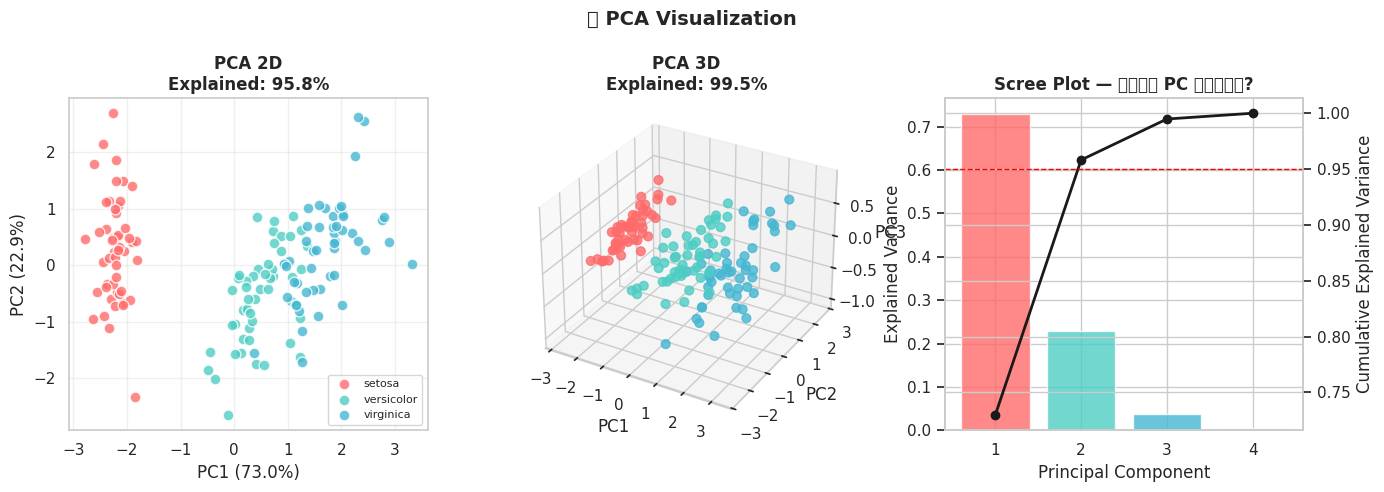

In [50]:
# 9️⃣ Matplotlib — PCA Visualization
print('🔍 PCA Plot — High Dimension → 2D তে দেখা')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(iris.data)

pca2 = PCA(n_components=2)
pca3 = PCA(n_components=3)
X_2d = pca2.fit_transform(X_scaled)
X_3d = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(131)
for i, (sp, color) in enumerate(zip(iris.target_names, COLORS)):
    mask = iris.target == i
    ax1.scatter(X_2d[mask,0], X_2d[mask,1], c=color, label=sp, s=60, alpha=0.8, edgecolors='white')
ax1.set_title(f'PCA 2D\nExplained: {pca2.explained_variance_ratio_.sum():.1%}', fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(132, projection='3d')
for i, (sp, color) in enumerate(zip(iris.target_names, COLORS)):
    mask = iris.target == i
    ax2.scatter(X_3d[mask,0], X_3d[mask,1], X_3d[mask,2],
                c=color, label=sp, s=40, alpha=0.8)
ax2.set_title(f'PCA 3D\nExplained: {pca3.explained_variance_ratio_.sum():.1%}', fontweight='bold')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.set_zlabel('PC3')

ax3 = fig.add_subplot(133)
pca_full = PCA().fit(X_scaled)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
ax3.bar(range(1,5), pca_full.explained_variance_ratio_,
        color=['#FF6B6B','#4ECDC4','#45B7D1','#F7B731'], alpha=0.8, label='Individual')
ax3_twin = ax3.twinx()
ax3_twin.plot(range(1,5), cumsum, 'ko-', linewidth=2, markersize=6, label='Cumulative')
ax3_twin.axhline(0.95, color='red', linewidth=1, linestyle='--')
ax3_twin.set_ylabel('Cumulative Explained Variance')
ax3.set_title('Scree Plot — কতটি PC দরকার?', fontweight='bold')
ax3.set_xlabel('Principal Component'); ax3.set_ylabel('Explained Variance')
ax3.set_xticks([1,2,3,4])

plt.suptitle('🔍 PCA Visualization', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

📊 Learning Curve — Data বাড়লে Model কতটা ভালো হয়?


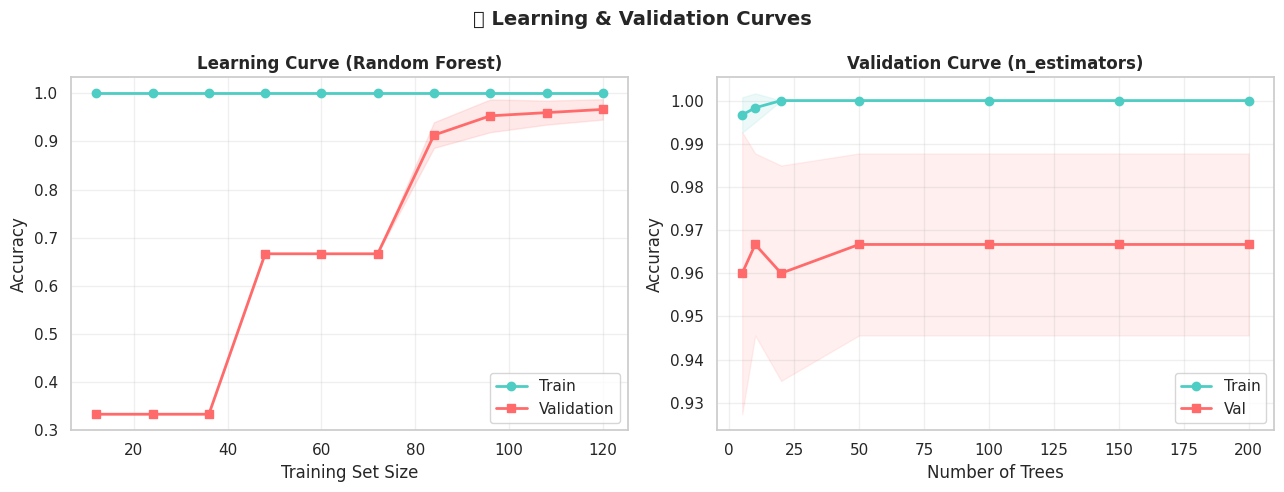

In [51]:
# 🔟 Matplotlib — Learning Curve ও Error Analysis
print('📊 Learning Curve — Data বাড়লে Model কতটা ভালো হয়?')

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=50, random_state=42),
    iris.data, iris.target, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy')

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(train_sizes, train_mean, 'o-', color='#4ECDC4', linewidth=2, markersize=6, label='Train')
axes[0].plot(train_sizes, val_mean, 's-', color='#FF6B6B', linewidth=2, markersize=6, label='Validation')
axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#4ECDC4')
axes[0].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#FF6B6B')
axes[0].set_title('Learning Curve (Random Forest)', fontweight='bold')
axes[0].set_xlabel('Training Set Size'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Validation Curve (n_estimators)
from sklearn.model_selection import validation_curve
n_range = [5, 10, 20, 50, 100, 150, 200]
tr_sc, va_sc = validation_curve(
    RandomForestClassifier(random_state=42),
    iris.data, iris.target,
    param_name='n_estimators', param_range=n_range, cv=5)

axes[1].plot(n_range, tr_sc.mean(axis=1), 'o-', color='#4ECDC4', linewidth=2, label='Train')
axes[1].plot(n_range, va_sc.mean(axis=1), 's-', color='#FF6B6B', linewidth=2, label='Val')
axes[1].fill_between(n_range, tr_sc.mean(1)-tr_sc.std(1), tr_sc.mean(1)+tr_sc.std(1), alpha=0.1, color='#4ECDC4')
axes[1].fill_between(n_range, va_sc.mean(1)-va_sc.std(1), va_sc.mean(1)+va_sc.std(1), alpha=0.1, color='#FF6B6B')
axes[1].set_title('Validation Curve (n_estimators)', fontweight='bold')
axes[1].set_xlabel('Number of Trees'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('📊 Learning & Validation Curves', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
# 🎨 PART 4 — Seaborn
### মোট 8টি আলাদা Statistical Plot

🌡️ Heatmap — Correlation ও Feature Relationship


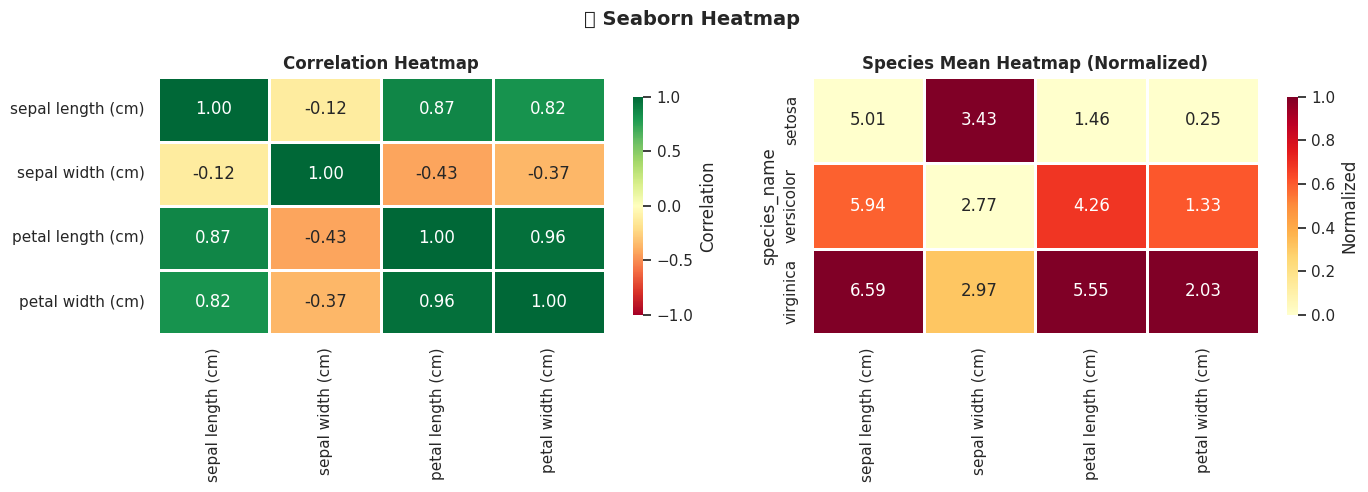

In [52]:
# 1️⃣ Seaborn — Heatmap
print('🌡️ Heatmap — Correlation ও Feature Relationship')
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation Heatmap
corr = df.iloc[:, :4].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[0], vmin=-1, vmax=1, linewidths=1,
            cbar_kws={'shrink': 0.85, 'label': 'Correlation'})
axes[0].set_title('Correlation Heatmap', fontweight='bold', fontsize=12)

# Species-wise Mean Heatmap
pivot = df.groupby('species_name').mean(numeric_only=True).iloc[:, :4]
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())  # normalize
sns.heatmap(pivot_norm, annot=pivot.round(2), fmt='.2f',
            cmap='YlOrRd', ax=axes[1], linewidths=1,
            cbar_kws={'shrink': 0.85, 'label': 'Normalized'})
axes[1].set_title('Species Mean Heatmap (Normalized)', fontweight='bold', fontsize=12)

plt.suptitle('🌡️ Seaborn Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

🎻 Violin Plot — Distribution Shape ও Spread


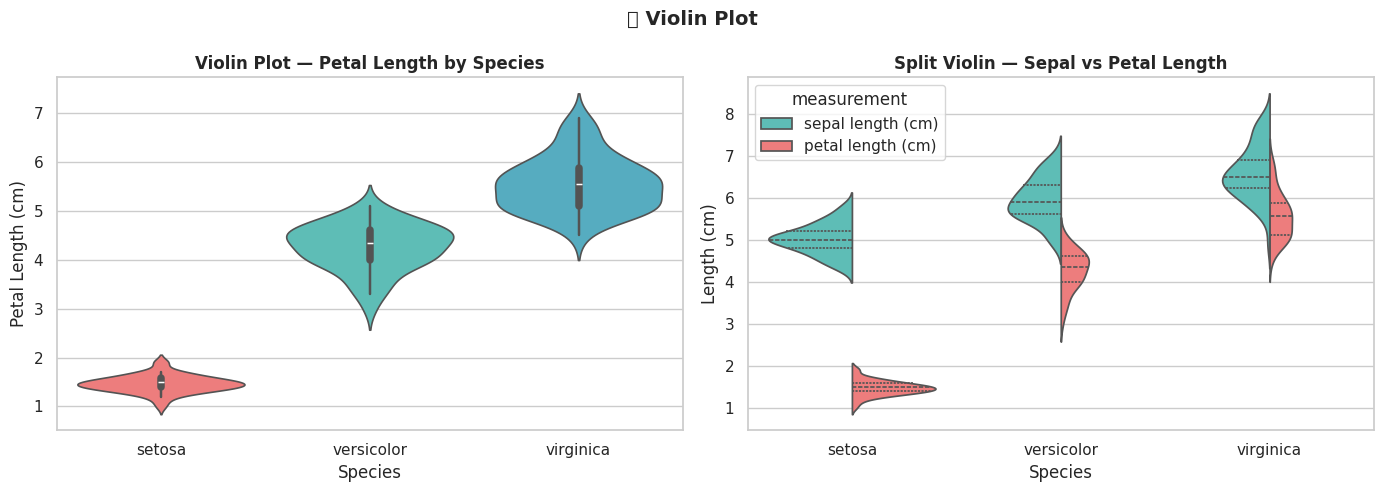

In [53]:
# 2️⃣ Seaborn — Violin Plot
print('🎻 Violin Plot — Distribution Shape ও Spread')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Standard Violin
sns.violinplot(data=df, x='species_name', y='petal length (cm)',
               palette=COLORS, ax=axes[0], inner='box', linewidth=1.2)
axes[0].set_title('Violin Plot — Petal Length by Species', fontweight='bold')
axes[0].set_xlabel('Species'); axes[0].set_ylabel('Petal Length (cm)')

# Split Violin (compare sepal vs petal)
df_melt = pd.melt(df[['species_name','sepal length (cm)','petal length (cm)']],
                   id_vars='species_name',
                   var_name='measurement', value_name='length')
sns.violinplot(data=df_melt, x='species_name', y='length',
               hue='measurement', split=True,
               palette=['#4ECDC4', '#FF6B6B'], ax=axes[1], inner='quartile')
axes[1].set_title('Split Violin — Sepal vs Petal Length', fontweight='bold')
axes[1].set_xlabel('Species'); axes[1].set_ylabel('Length (cm)')

plt.suptitle('🎻 Violin Plot', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

📈 KDE Plot — Probability Density


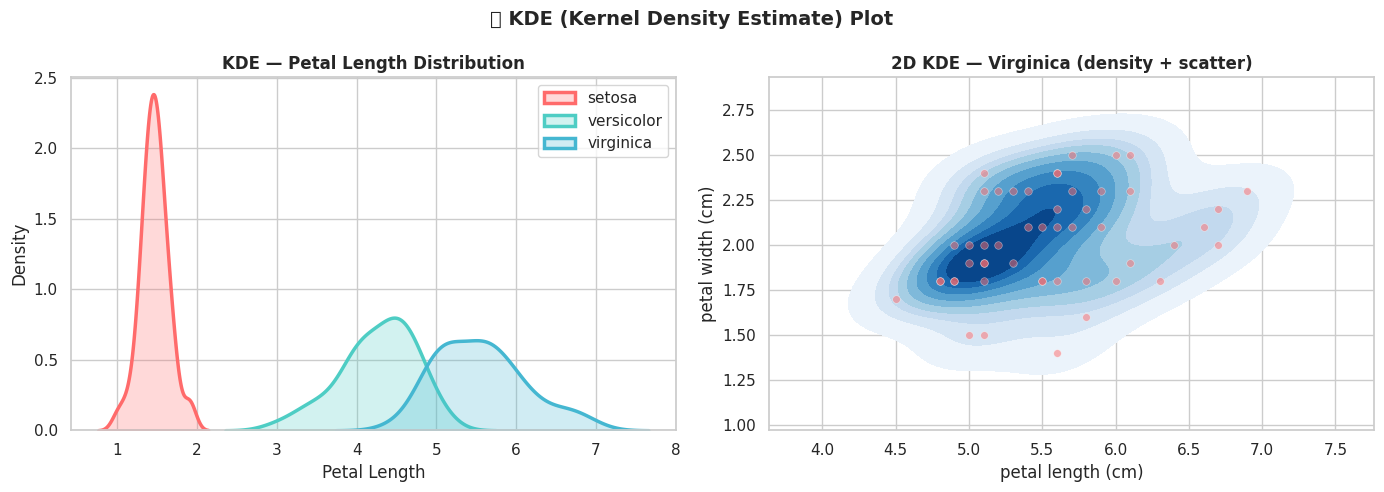

KDE = Histogram এর smooth version — তুলনা করতে সহজ


In [54]:
# 3️⃣ Seaborn — KDE Plot
print('📈 KDE Plot — Probability Density')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1D KDE
for sp, color in zip(['setosa','versicolor','virginica'], COLORS):
    mask = df['species_name'] == sp
    sns.kdeplot(data=df[mask], x='petal length (cm)', label=sp,
                color=color, fill=True, alpha=0.25, linewidth=2.5, ax=axes[0])
axes[0].set_title('KDE — Petal Length Distribution', fontweight='bold')
axes[0].set_xlabel('Petal Length'); axes[0].legend()

# 2D KDE
sns.kdeplot(data=df[df['species_name']=='virginica'],
            x='petal length (cm)', y='petal width (cm)',
            cmap='Blues', fill=True, levels=10, ax=axes[1])
sns.scatterplot(data=df[df['species_name']=='virginica'],
                x='petal length (cm)', y='petal width (cm)',
                color='#FF6B6B', s=30, alpha=0.5, ax=axes[1])
axes[1].set_title('2D KDE — Virginica (density + scatter)', fontweight='bold')

plt.suptitle('📈 KDE (Kernel Density Estimate) Plot', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('KDE = Histogram এর smooth version — তুলনা করতে সহজ')

🔍 Pair Plot — Feature Selection এর জন্য সবচেয়ে কার্যকর


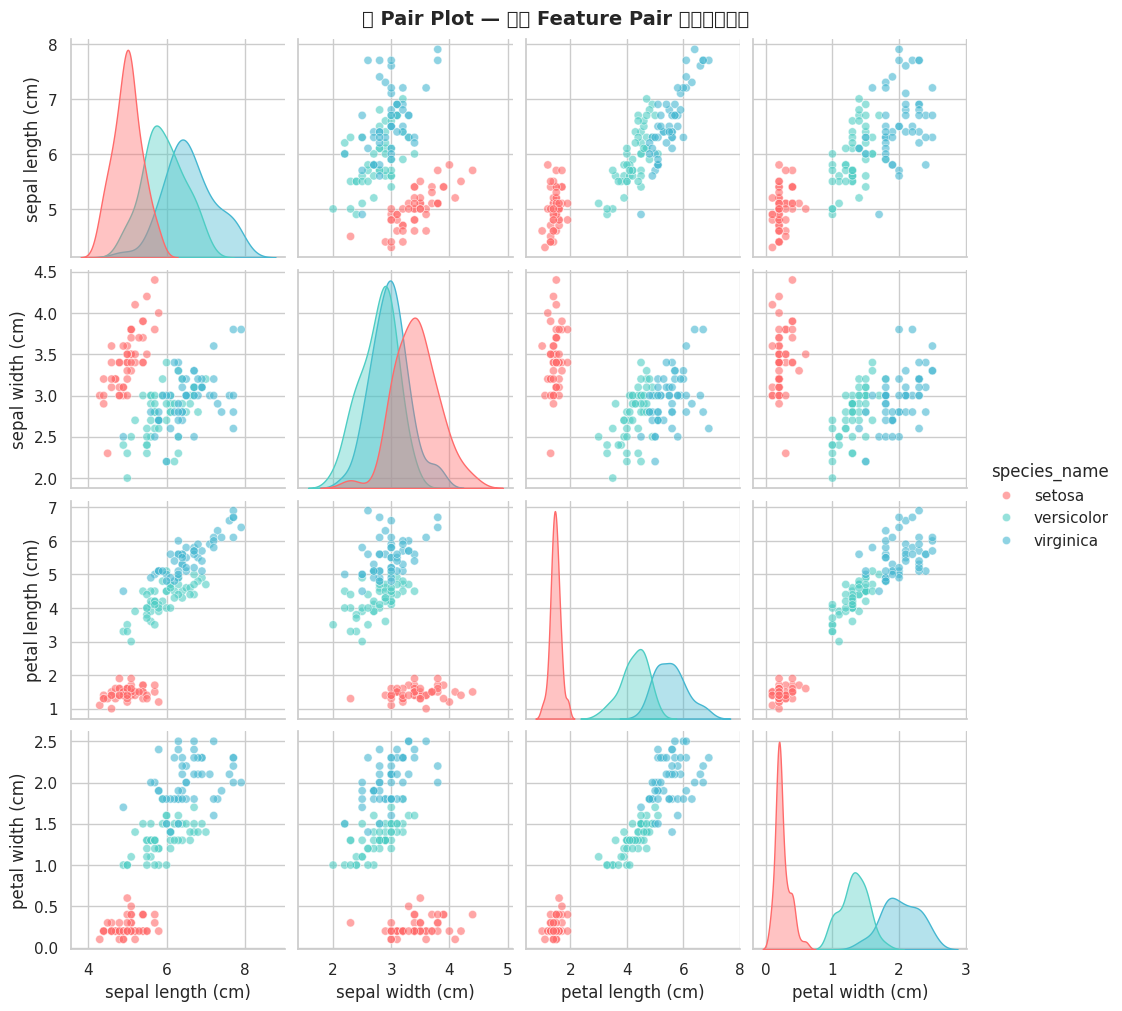

Diagonal: প্রতিটি feature এর distribution
Off-diagonal: দুটি feature এর scatter → class separation দেখো


In [55]:
# 4️⃣ Seaborn — Pair Plot
print('🔍 Pair Plot — Feature Selection এর জন্য সবচেয়ে কার্যকর')

g = sns.pairplot(df[features + ['species_name']],
                 hue='species_name',
                 palette=dict(zip(['setosa','versicolor','virginica'], COLORS)),
                 diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 35, 'edgecolors': 'white'},
                 diag_kws={'fill': True, 'alpha': 0.4})
g.fig.suptitle('🔍 Pair Plot — সব Feature Pair একসাথে', y=1.01,
               fontsize=14, fontweight='bold')
plt.show()
print('Diagonal: প্রতিটি feature এর distribution')
print('Off-diagonal: দুটি feature এর scatter → class separation দেখো')

📉 Regression Plot — Linear Relationship ও Confidence Interval


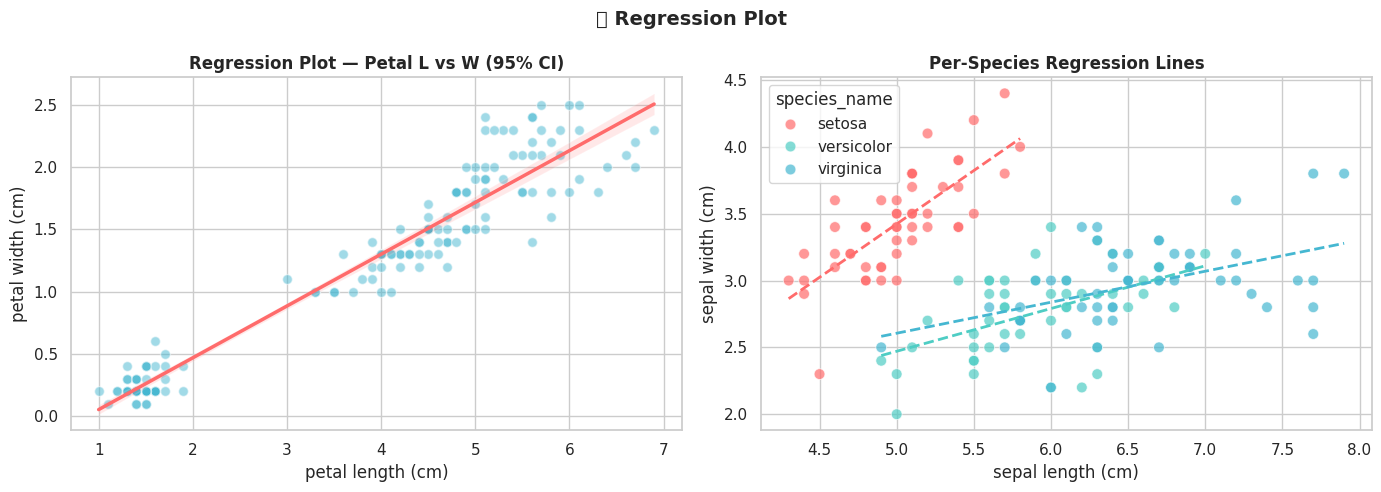

In [56]:
# 5️⃣ Seaborn — Regression Plot
print('📉 Regression Plot — Linear Relationship ও Confidence Interval')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall Regression
sns.regplot(data=df, x='petal length (cm)', y='petal width (cm)',
            scatter_kws={'alpha': 0.5, 'color': '#45B7D1', 's': 50, 'edgecolors': 'white'},
            line_kws={'color': '#FF6B6B', 'linewidth': 2.5}, ci=95, ax=axes[0])
axes[0].set_title('Regression Plot — Petal L vs W (95% CI)', fontweight='bold')

# lmplot by group
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)',
                hue='species_name', palette=COLORS, ax=axes[1], s=60, alpha=0.7)
for sp, color in zip(['setosa','versicolor','virginica'], COLORS):
    mask = df['species_name'] == sp
    sns.regplot(data=df[mask], x='sepal length (cm)', y='sepal width (cm)',
                scatter=False, ci=None,
                line_kws={'color': color, 'linewidth': 2, 'linestyle': '--'},
                ax=axes[1])
axes[1].set_title('Per-Species Regression Lines', fontweight='bold')

plt.suptitle('📉 Regression Plot', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

🔘 Strip + Swarm Plot — Individual Points দেখা


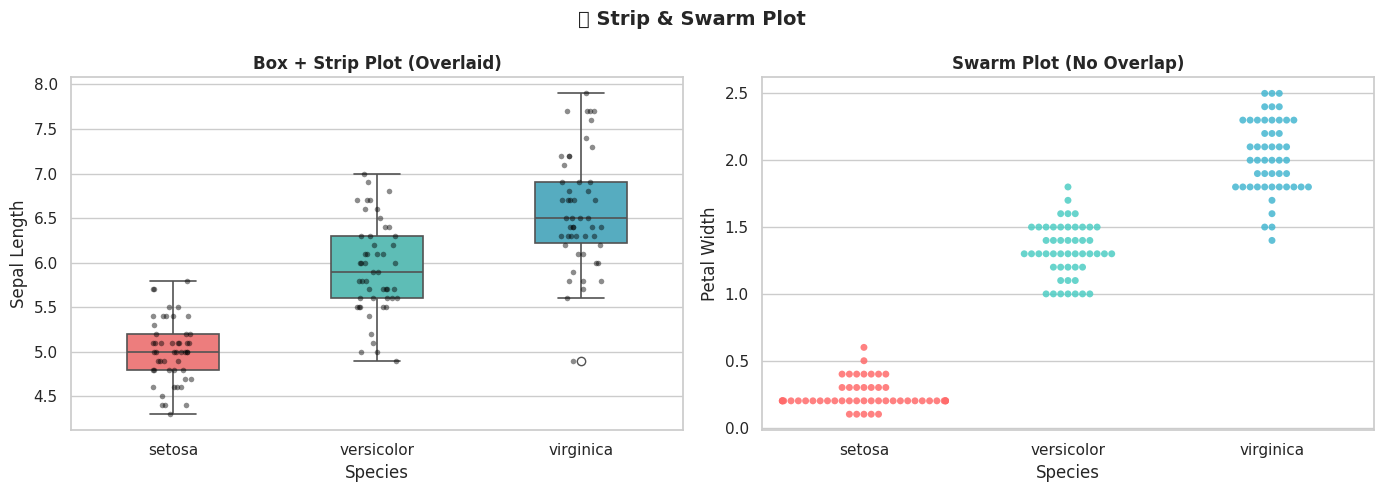

Strip: jitter দিয়ে random; Swarm: overlap avoid করে সাজায়


In [57]:
# 6️⃣ Seaborn — Strip Plot ও Swarm Plot
print('🔘 Strip + Swarm Plot — Individual Points দেখা')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box + Strip combined
sns.boxplot(data=df, x='species_name', y='sepal length (cm)',
            palette=COLORS, ax=axes[0], width=0.45, linewidth=1.2)
sns.stripplot(data=df, x='species_name', y='sepal length (cm)',
              color='black', size=4, alpha=0.45, jitter=True, ax=axes[0])
axes[0].set_title('Box + Strip Plot (Overlaid)', fontweight='bold')
axes[0].set_xlabel('Species'); axes[0].set_ylabel('Sepal Length')

# Swarm Plot (no overlap)
sns.swarmplot(data=df, x='species_name', y='petal width (cm)',
              palette=COLORS, ax=axes[1], size=5, alpha=0.85)
axes[1].set_title('Swarm Plot (No Overlap)', fontweight='bold')
axes[1].set_xlabel('Species'); axes[1].set_ylabel('Petal Width')

plt.suptitle('🔘 Strip & Swarm Plot', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print('Strip: jitter দিয়ে random; Swarm: overlap avoid করে সাজায়')

🔗 Joint Plot — Main Distribution + Marginal Distribution


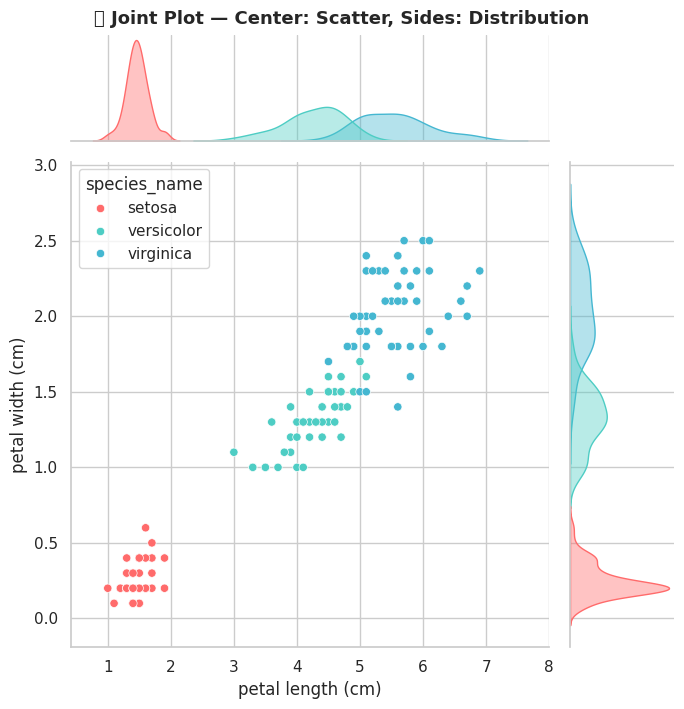

Center = scatter, Top = X distribution, Right = Y distribution


In [58]:
# 7️⃣ Seaborn — Joint Plot
print('🔗 Joint Plot — Main Distribution + Marginal Distribution')

g = sns.jointplot(data=df,
                  x='petal length (cm)', y='petal width (cm)',
                  hue='species_name',
                  palette=dict(zip(['setosa','versicolor','virginica'], COLORS)),
                  height=7, ratio=4,
                  marginal_kws={'fill': True, 'alpha': 0.4})
g.figure.suptitle('🔗 Joint Plot — Center: Scatter, Sides: Distribution',
                   y=1.01, fontsize=13, fontweight='bold')
plt.show()
print('Center = scatter, Top = X distribution, Right = Y distribution')

🗂️ FacetGrid — প্রতিটি Category আলাদা Subplot এ


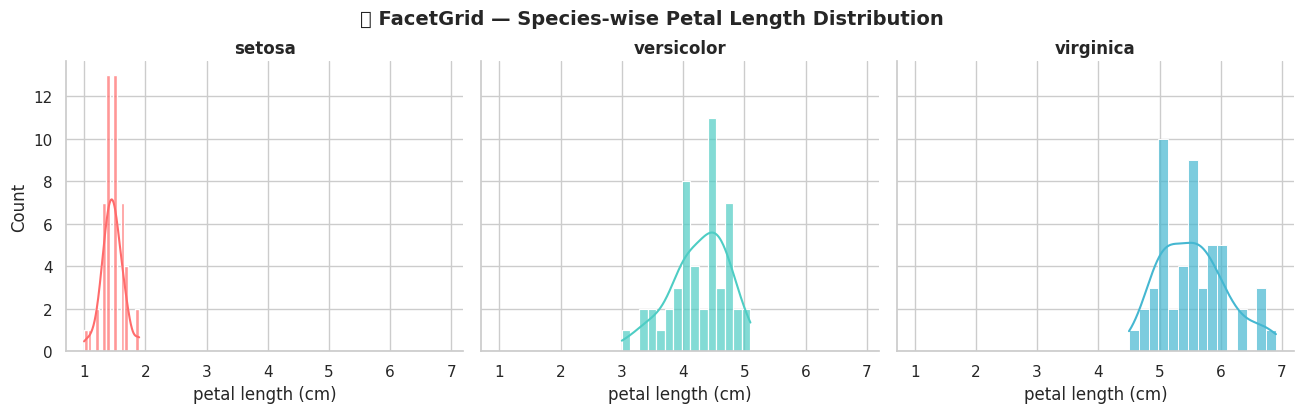

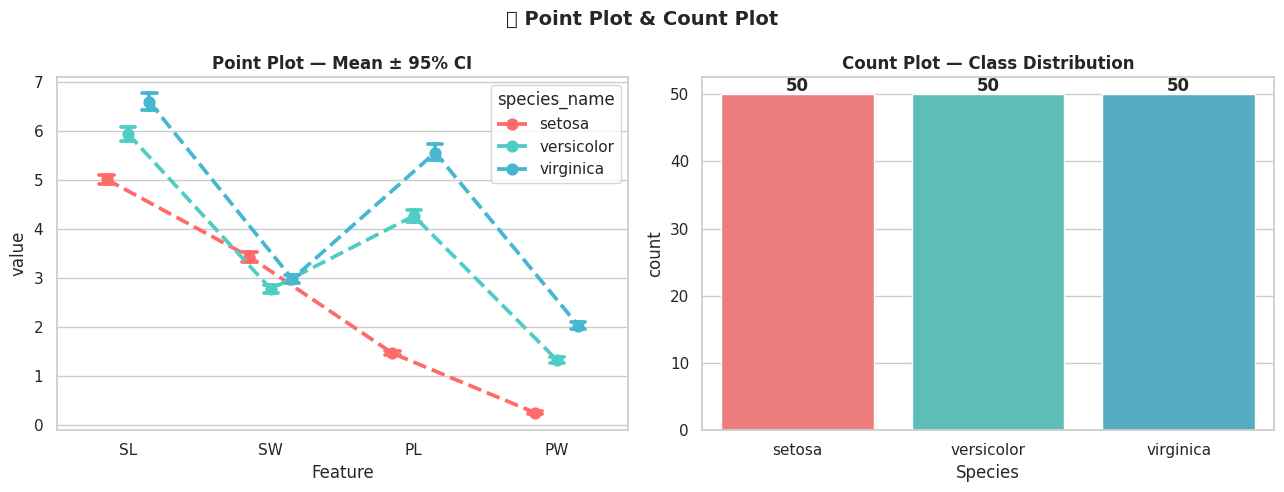

In [59]:
# 8️⃣ Seaborn — FacetGrid (Subplot by Category)
print('🗂️ FacetGrid — প্রতিটি Category আলাদা Subplot এ')

# FacetGrid: species অনুযায়ী আলাদা histogram
g = sns.FacetGrid(df, col='species_name', hue='species_name',
                   palette=dict(zip(['setosa','versicolor','virginica'], COLORS)),
                   height=4, aspect=1.1)
g.map(sns.histplot, 'petal length (cm)', bins=15, kde=True, alpha=0.7)
g.set_titles('{col_name}', fontweight='bold', fontsize=12)
g.figure.suptitle('🗂️ FacetGrid — Species-wise Petal Length Distribution',
                   y=1.03, fontsize=14, fontweight='bold')
plt.show()

# Point Plot (Mean + CI)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df_melt2 = pd.melt(df, id_vars='species_name',
                    value_vars=features,
                    var_name='feature', value_name='value')
sns.pointplot(data=df_melt2, x='feature', y='value', hue='species_name',
              palette=dict(zip(['setosa','versicolor','virginica'], COLORS)),
              ax=axes[0], dodge=0.3, capsize=0.1, linestyles='--')
axes[0].set_title('Point Plot — Mean ± 95% CI', fontweight='bold')
axes[0].set_xticklabels(['SL','SW','PL','PW'])
axes[0].set_xlabel('Feature')

# Count Plot
sns.countplot(data=df, x='species_name', palette=COLORS, ax=axes[1], edgecolor='white')
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width()/2, p.get_height() + 0.5,
                 str(int(p.get_height())), ha='center', fontweight='bold')
axes[1].set_title('Count Plot — Class Distribution', fontweight='bold')
axes[1].set_xlabel('Species')

plt.suptitle('📊 Point Plot & Count Plot', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
# 📋 PART 5: Summary - কোন Library কী কাজে লাগে

| Library | প্রধান কাজ | ML/DL এ ব্যবহার | কোন Dataset এ? |
|---------|-----------|-----------------|----------------|
| **NumPy** | Array/Matrix operations, Math | Weight matrices, Loss functions, Activation functions | সব ধরনের Numerical Data |
| **Pandas** | Data Load, Clean, Transform | Feature Engineering, EDA, Preprocessing | CSV, Excel, SQL - সব |
| **Matplotlib** | সব ধরনের Plot | Training curves, Confusion Matrix, ROC Curve | যেকোনো Data |
| **Seaborn** | Statistical Visualization | Correlation Heatmap, Distribution, Pair Plot | Tabular/Structured Data |

---
### 🏆 Plot Summary:

| Plot | Library | ML Use Case |
|------|---------|-------------|
| Line Plot | Matplotlib | Training/Validation Loss ও Accuracy curve |
| Bar Plot | Matplotlib | Feature Importance |
| Scatter Plot | Matplotlib/Seaborn | Feature relationships, Clusters |
| Histogram | Matplotlib/Seaborn | Feature distribution |
| Box Plot | Matplotlib/Seaborn | Outlier detection |
| Violin Plot | Seaborn | Distribution shape comparison |
| Heatmap | Seaborn | Correlation matrix, Confusion matrix |
| Pair Plot | Seaborn | Feature selection |
| KDE Plot | Seaborn | Class distributions |
| ROC Curve | Matplotlib | Classifier evaluation |
| Confusion Matrix | Matplotlib | Classification results |
| Regression Plot | Seaborn | Linear relationships |
| PCA Plot | Matplotlib | Dimensionality reduction visualization |
| Learning Curve | Matplotlib | Model performance vs data size |


---
# 📋 Summary Table

| Cell | Library | Plot/Topic | ML Use Case |
|------|---------|------------|-------------|
| 1 | NumPy | Array তৈরি | Feature Vector, Weight Matrix |
| 2 | NumPy | Activation Functions | Neuron Output |
| 3 | NumPy | Matrix Multiplication | Forward Pass |
| 4 | NumPy | Loss Functions | BCE, MSE |
| 5 | NumPy | Normalization | Feature Scaling |
| 6 | Pandas | Dataset Load | Data Ingestion |
| 7 | Pandas | EDA | Descriptive Stats |
| 8 | Pandas | Missing Values | Data Cleaning |
| 9 | Pandas | Feature Engineering | New Features |
| 10 | Pandas | Correlation | Feature Selection |
| 11 | Matplotlib | Line Plot | Training Curves |
| 12 | Matplotlib | Scatter Plot | Class Separation |
| 13 | Matplotlib | Bar Plot | Feature Importance |
| 14 | Matplotlib | Histogram | Distribution |
| 15 | Matplotlib | Box Plot | Outlier |
| 16 | Matplotlib | Pie/Donut | Class Balance |
| 17 | Matplotlib | Confusion Matrix | Classification |
| 18 | Matplotlib | ROC Curve | AUC Score |
| 19 | Matplotlib | PCA Plot | Dimensionality |
| 20 | Matplotlib | Learning Curve | Data Size Effect |
| 21 | Seaborn | Heatmap | Correlation |
| 22 | Seaborn | Violin Plot | Distribution |
| 23 | Seaborn | KDE Plot | Density |
| 24 | Seaborn | Pair Plot | Feature Selection |
| 25 | Seaborn | Regression Plot | Linear Fit |
| 26 | Seaborn | Strip/Swarm | Individual Points |
| 27 | Seaborn | Joint Plot | 2D Distribution |
| 28 | Seaborn | FacetGrid | Per-Category Plot |